In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

eea_gnn_ml_competition_1_path = kagglehub.competition_download('eea-gnn-ml-competition-1')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/eea-gnn-ml-competition-1/sample_submission.csv
/kaggle/input/eea-gnn-ml-competition-1/train.csv
/kaggle/input/eea-gnn-ml-competition-1/test.csv


In [ ]:
train = pd.read_csv("/kaggle/input/eea-gnn-ml-competition-1/train.csv")
test= pd.read_csv("/kaggle/input/eea-gnn-ml-competition-1/test.csv")
train.head()

,Transaction_ID,Customer_ID,Transaction_Amount,Transaction_Type,Transaction_Location,Transaction_Time,Device_Used,Account_Age,Credit_Score,Previous_Fraud,Is_Fraud
0,T9386,C1003,7903.56,Withdrawal,"Bradleystad, Netherlands",2025-01-16 08:16:51,POS Terminal,9,643,1,1
1,T4516,C5528,4799.57,Withdrawal,"Kristinfort, Northern Mariana Islands",2025-01-14 09:44:26,ATM,19,701,0,0
2,T3107,C4931,5399.12,Online Payment,"Odommouth, Iran",2025-02-13 04:39:41,ATM,10,330,0,0
3,T1661,C9440,4497.85,Transfer,"Martinezberg, Sweden",2025-01-11 11:35:27,POS Terminal,20,722,1,0
4,T5937,C4280,4186.71,Deposit,"Gabrielleborough, Guatemala",2025-01-06 05:37:29,ATM,7,411,0,0


In [ ]:
test.head()

,Transaction_ID,Customer_ID,Transaction_Amount,Transaction_Type,Transaction_Location,Transaction_Time,Device_Used,Account_Age,Credit_Score,Previous_Fraud
0,T335,C2233,8307.65,Transfer,"East Kennethfurt, Mexico",2025-02-15 18:11:36,Mobile,14,390,0
1,T3754,C6070,969.26,Deposit,"Hayesborough, Colombia",2025-01-28 06:01:50,POS Terminal,14,322,1
2,T7224,C9100,8266.77,Deposit,"Stephaniestad, Suriname",2025-02-09 10:21:44,Mobile,10,531,0
3,T789,C3038,9044.71,Withdrawal,"Frostfort, Sweden",2025-02-04 09:19:17,ATM,15,850,1
4,T5835,C7516,6207.71,Deposit,"East John, Tunisia",2025-01-11 14:25:59,ATM,7,343,1


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Transaction_ID        8000 non-null   object 
 1   Customer_ID           8000 non-null   object 
 2   Transaction_Amount    8000 non-null   float64
 3   Transaction_Type      8000 non-null   object 
 4   Transaction_Location  8000 non-null   object 
 5   Transaction_Time      8000 non-null   object 
 6   Device_Used           8000 non-null   object 
 7   Account_Age           8000 non-null   int64  
 8   Credit_Score          8000 non-null   int64  
 9   Previous_Fraud        8000 non-null   int64  
 10  Is_Fraud              8000 non-null   int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 687.6+ KB


In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Transaction_ID        2000 non-null   object 
 1   Customer_ID           2000 non-null   object 
 2   Transaction_Amount    2000 non-null   float64
 3   Transaction_Type      2000 non-null   object 
 4   Transaction_Location  2000 non-null   object 
 5   Transaction_Time      2000 non-null   object 
 6   Device_Used           2000 non-null   object 
 7   Account_Age           2000 non-null   int64  
 8   Credit_Score          2000 non-null   int64  
 9   Previous_Fraud        2000 non-null   int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 156.4+ KB


In [ ]:
unique_values = train.nunique()
print(unique_values)

Transaction_ID          8000
Customer_ID             5289
Transaction_Amount      7968
Transaction_Type           4
Transaction_Location    7984
Transaction_Time        7994
Device_Used                4
Account_Age               20
Credit_Score             551
Previous_Fraud             2
Is_Fraud                   2
dtype: int64


In [ ]:
# cust_avg = train.groupby('Customer_ID')['Transaction_Amount'].transform('mean')
# train['Amt_Pct_of_Avg'] = train['Transaction_Amount'] / (cust_avg + 0.01)
# cust_avg_test = test.groupby('Customer_ID')['Transaction_Amount'].transform('mean')
# test['Amt_Pct_of_Avg'] = test['Transaction_Amount'] / (cust_avg_test + 0.01)

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Transaction_ID        8000 non-null   object 
 1   Customer_ID           8000 non-null   object 
 2   Transaction_Amount    8000 non-null   float64
 3   Transaction_Type      8000 non-null   object 
 4   Transaction_Location  8000 non-null   object 
 5   Transaction_Time      8000 non-null   object 
 6   Device_Used           8000 non-null   object 
 7   Account_Age           8000 non-null   int64  
 8   Credit_Score          8000 non-null   int64  
 9   Previous_Fraud        8000 non-null   int64  
 10  Is_Fraud              8000 non-null   int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 687.6+ KB


In [ ]:
def preprocess(df):
    df['Transaction_Time'] = pd.to_datetime(df['Transaction_Time'])
    df = df.sort_values(by=['Customer_ID', 'Transaction_Time'])
    df['Time_Since_Last'] = df.groupby('Customer_ID')['Transaction_Time'].diff().dt.total_seconds().fillna(999999)
    df = df.set_index('Transaction_Time')
    df['Trans_Count_24h'] = df.groupby('Customer_ID')['Transaction_Amount'].rolling('24h').count().reset_index(level=0, drop=True)
    df['Avg_Amt_24h'] = df.groupby('Customer_ID')['Transaction_Amount'].rolling('24h').mean().reset_index(level=0, drop=True)
    df = df.reset_index()
    df['Hour'] = df['Transaction_Time'].dt.hour
    df['Day_of_Week'] = df['Transaction_Time'].dt.dayofweek
    df['Country'] = df['Transaction_Location'].apply(lambda x: x.split(',')[-1].strip() if ',' in str(x) else 'Unknown')

    df['Amt_to_Credit_Ratio'] = df['Transaction_Amount'] / (df['Credit_Score'] + 1)
    df['Amt_to_Age_Ratio'] = df['Transaction_Amount'] / (df['Account_Age'] + 1)

    cust_avg = df.groupby('Customer_ID')['Transaction_Amount'].transform('mean')
    df['Amt_vs_Avg_Ratio'] = df['Transaction_Amount'] / (cust_avg + 1)
    df['Log_Amount'] = np.log1p(df['Transaction_Amount'])

    return df.drop(['Transaction_ID', 'Customer_ID', 'Transaction_Location', 'Transaction_Time'], axis=1)

In [ ]:
def preprocess_test(df):
    df['Transaction_Time'] = pd.to_datetime(df['Transaction_Time'])
    df = df.sort_values(by=['Customer_ID', 'Transaction_Time'])
    df['Time_Since_Last'] = df.groupby('Customer_ID')['Transaction_Time'].diff().dt.total_seconds().fillna(999999)
    df = df.set_index('Transaction_Time')
    df['Trans_Count_24h'] = df.groupby('Customer_ID')['Transaction_Amount'].rolling('24h').count().reset_index(level=0, drop=True)
    df['Avg_Amt_24h'] = df.groupby('Customer_ID')['Transaction_Amount'].rolling('24h').mean().reset_index(level=0, drop=True)
    df = df.reset_index()
    df['Hour'] = df['Transaction_Time'].dt.hour
    df['Day_of_Week'] = df['Transaction_Time'].dt.dayofweek
    df['Country'] = df['Transaction_Location'].apply(lambda x: x.split(',')[-1].strip() if ',' in str(x) else 'Unknown')

    df['Amt_to_Credit_Ratio'] = df['Transaction_Amount'] / (df['Credit_Score'] + 1)
    df['Amt_to_Age_Ratio'] = df['Transaction_Amount'] / (df['Account_Age'] + 1)

    cust_avg = df.groupby('Customer_ID')['Transaction_Amount'].transform('mean')
    df['Amt_vs_Avg_Ratio'] = df['Transaction_Amount'] / (cust_avg + 1)
    df['Log_Amount'] = np.log1p(df['Transaction_Amount'])

    return df.drop(['Customer_ID', 'Transaction_Location', 'Transaction_Time'], axis=1)

In [ ]:
train_proc = preprocess(train)
test_proc = preprocess_test(test)

In [ ]:
train_proc.head()

,Transaction_Amount,Transaction_Type,Device_Used,Account_Age,Credit_Score,Previous_Fraud,Is_Fraud,Time_Since_Last,Trans_Count_24h,Avg_Amt_24h,Hour,Day_of_Week,Country,Amt_to_Credit_Ratio,Amt_to_Age_Ratio,Amt_vs_Avg_Ratio,Log_Amount
0,3770.21,Online Payment,ATM,5,829,1,0,999999.0,1.0,3770.21,22,2,Saint Martin,4.542422,628.368333,1.203609,8.235151
1,2492.63,Online Payment,POS Terminal,11,354,1,1,2460353.0,1.0,2492.63,9,3,Angola,7.021493,207.719167,0.795752,7.821495
2,7903.56,Withdrawal,POS Terminal,9,643,1,1,999999.0,1.0,7903.56,8,3,Netherlands,12.272609,790.356000,1.601420,8.975195
3,1965.13,Deposit,POS Terminal,11,531,1,0,2664523.0,1.0,1965.13,4,6,Suriname,3.693853,163.760833,0.398175,7.583822
4,2039.87,Withdrawal,Web,17,615,1,0,999999.0,1.0,2039.87,14,4,Algeria,3.311477,113.326111,0.999510,7.621131


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
all_countries = pd.concat([train_proc['Country'], test_proc['Country']])
le.fit(all_countries)

LabelEncoder()

In [ ]:
train_proc['Country'] = le.transform(train_proc['Country'])
test_proc['Country'] = le.transform(test_proc['Country'])
train_proc.head()

,Transaction_Amount,Transaction_Type,Device_Used,Account_Age,Credit_Score,Previous_Fraud,Is_Fraud,Time_Since_Last,Trans_Count_24h,Avg_Amt_24h,Hour,Day_of_Week,Country,Amt_to_Credit_Ratio,Amt_to_Age_Ratio,Amt_vs_Avg_Ratio,Log_Amount
0,3770.21,Online Payment,ATM,5,829,1,0,999999.0,1.0,3770.21,22,2,185,4.542422,628.368333,1.203609,8.235151
1,2492.63,Online Payment,POS Terminal,11,354,1,1,2460353.0,1.0,2492.63,9,3,5,7.021493,207.719167,0.795752,7.821495
2,7903.56,Withdrawal,POS Terminal,9,643,1,1,999999.0,1.0,7903.56,8,3,151,12.272609,790.356000,1.601420,8.975195
3,1965.13,Deposit,POS Terminal,11,531,1,0,2664523.0,1.0,1965.13,4,6,206,3.693853,163.760833,0.398175,7.583822
4,2039.87,Withdrawal,Web,17,615,1,0,999999.0,1.0,2039.87,14,4,2,3.311477,113.326111,0.999510,7.621131


In [ ]:
train_final = pd.get_dummies(train_proc,columns=['Transaction_Type', 'Device_Used'], drop_first=True)
test_final = pd.get_dummies(test_proc, columns=['Transaction_Type', 'Device_Used'], drop_first=True)
train_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Transaction_Amount               8000 non-null   float64
 1   Account_Age                      8000 non-null   int64  
 2   Credit_Score                     8000 non-null   int64  
 3   Previous_Fraud                   8000 non-null   int64  
 4   Is_Fraud                         8000 non-null   int64  
 5   Time_Since_Last                  8000 non-null   float64
 6   Trans_Count_24h                  8000 non-null   float64
 7   Avg_Amt_24h                      8000 non-null   float64
 8   Hour                             8000 non-null   int32  
 9   Day_of_Week                      8000 non-null   int32  
 10  Country                          8000 non-null   int64  
 11  Amt_to_Credit_Ratio              8000 non-null   float64
 12  Amt_to_Age_Ratio    

In [ ]:
test_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Transaction_ID                   2000 non-null   object 
 1   Transaction_Amount               2000 non-null   float64
 2   Account_Age                      2000 non-null   int64  
 3   Credit_Score                     2000 non-null   int64  
 4   Previous_Fraud                   2000 non-null   int64  
 5   Time_Since_Last                  2000 non-null   float64
 6   Trans_Count_24h                  2000 non-null   float64
 7   Avg_Amt_24h                      2000 non-null   float64
 8   Hour                             2000 non-null   int32  
 9   Day_of_Week                      2000 non-null   int32  
 10  Country                          2000 non-null   int64  
 11  Amt_to_Credit_Ratio              2000 non-null   float64
 12  Amt_to_Age_Ratio    

In [ ]:
test_final.isnull().sum()

Transaction_ID                     0
Transaction_Amount                 0
Account_Age                        0
Credit_Score                       0
Previous_Fraud                     0
Time_Since_Last                    0
Trans_Count_24h                    0
Avg_Amt_24h                        0
Hour                               0
Day_of_Week                        0
Country                            0
Amt_to_Credit_Ratio                0
Amt_to_Age_Ratio                   0
Amt_vs_Avg_Ratio                   0
Log_Amount                         0
Transaction_Type_Online Payment    0
Transaction_Type_Transfer          0
Transaction_Type_Withdrawal        0
Device_Used_Mobile                 0
Device_Used_POS Terminal           0
Device_Used_Web                    0
dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
X = train_final.drop(['Is_Fraud'], axis=1)
y = train_final['Is_Fraud']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6400 entries, 5359 to 1529
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Transaction_Amount               6400 non-null   float64
 1   Account_Age                      6400 non-null   int64  
 2   Credit_Score                     6400 non-null   int64  
 3   Previous_Fraud                   6400 non-null   int64  
 4   Time_Since_Last                  6400 non-null   float64
 5   Trans_Count_24h                  6400 non-null   float64
 6   Avg_Amt_24h                      6400 non-null   float64
 7   Hour                             6400 non-null   int32  
 8   Day_of_Week                      6400 non-null   int32  
 9   Country                          6400 non-null   int64  
 10  Amt_to_Credit_Ratio              6400 non-null   float64
 11  Amt_to_Age_Ratio                 6400 non-null   float64
 12  Amt_vs_Avg_Ratio      

In [ ]:
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
print("--- Validation Metrics ---")
y_pred = model.predict(X_val)
print(classification_report(y_val, y_pred))

--- Validation Metrics ---
              precision    recall  f1-score   support

           0       0.75      0.93      0.83      1146
           1       0.56      0.21      0.31       454

    accuracy                           0.73      1600
   macro avg       0.65      0.57      0.57      1600
weighted avg       0.70      0.73      0.68      1600



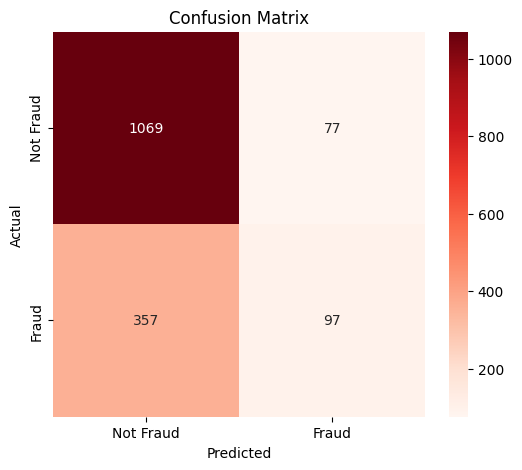

In [ ]:
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.title(f'Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
y_probs = model.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores)]
y_val_pred_custom = (y_probs >= best_threshold).astype(int)
print(f"--- Metrics at Threshold {best_threshold} ---")
print(classification_report(y_val, y_val_pred_custom))

--- Metrics at Threshold 0.23 ---
              precision    recall  f1-score   support

           0       0.88      0.52      0.66      1146
           1       0.40      0.81      0.54       454

    accuracy                           0.61      1600
   macro avg       0.64      0.67      0.60      1600
weighted avg       0.74      0.61      0.62      1600



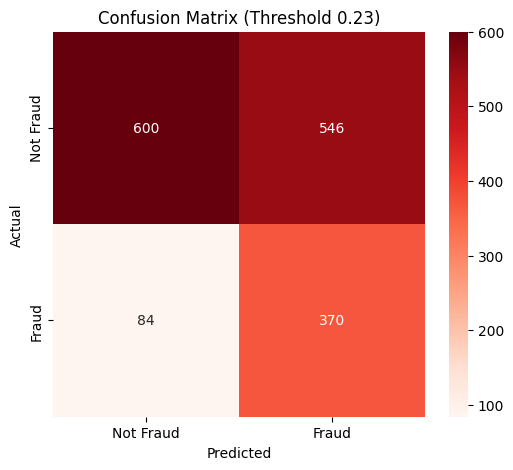

In [ ]:
cm = confusion_matrix(y_val, y_val_pred_custom)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.title(f'Confusion Matrix (Threshold {best_threshold})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print(f"Original training shape: {y_train.value_counts()}")
print(f"Resampled training shape: {y_train_res.value_counts()}")

Original training shape: Is_Fraud
0    4584
1    1816
Name: count, dtype: int64
Resampled training shape: Is_Fraud
1    4584
0    4584
Name: count, dtype: int64


In [ ]:
model_smote = RandomForestClassifier(n_estimators=200, random_state=42)
model_smote.fit(X_train_res, y_train_res)
y_pred_smote = model_smote.predict(X_val)

In [ ]:
y_val_probs_smote = model_smote.predict_proba(X_val)[:, 1]
precision_smote, recall_smote, thresholds_smote = precision_recall_curve(y_val, y_val_probs_smote)
f1_scores_smote = 2 * (precision_smote * recall_smote) / (precision_smote + recall_smote + 1e-8)
best_threshold_smote = thresholds_smote[np.argmax(f1_scores_smote)]
y_val_pred_smote = (y_val_probs_smote >= best_threshold_smote).astype(int)
print(f"--- Metrics at Threshold SMOTE {best_threshold_smote} ---")
print(classification_report(y_val, y_val_pred_smote))

--- Metrics at Threshold SMOTE 0.33 ---
              precision    recall  f1-score   support

           0       0.86      0.48      0.62      1146
           1       0.38      0.81      0.52       454

    accuracy                           0.57      1600
   macro avg       0.62      0.64      0.57      1600
weighted avg       0.73      0.57      0.59      1600



In [ ]:
model_max_f1 = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight='balanced',
    random_state=42
)
model_max_f1.fit(X_train, y_train)
y_probs = model_max_f1.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores)]
y_pred_optimized = (y_probs >= best_threshold).astype(int)
print(f"Maximum F1 Threshold Found: {best_threshold:.4f}")
print("--- Optimized Performance ---")
print(classification_report(y_val, y_pred_optimized))

Maximum F1 Threshold Found: 0.3669
--- Optimized Performance ---
              precision    recall  f1-score   support

           0       0.87      0.59      0.70      1146
           1       0.43      0.78      0.55       454

    accuracy                           0.64      1600
   macro avg       0.65      0.68      0.63      1600
weighted avg       0.75      0.64      0.66      1600



In [ ]:
def check_feature_impact(X_train, y_train, X_val, y_val):
    # 1. Get Baseline
    model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    model.fit(X_train, y_train)

    def get_f1(m, x, y):
        probs = m.predict_proba(x)[:, 1]
        p, r, t = precision_recall_curve(y, probs)
        return np.max(2 * (p * r) / (p + r + 1e-8))

    baseline_f1 = get_f1(model, X_val, y_val)
    print(f"Baseline F1: {baseline_f1:.4f}\n")

    # 2. Test dropping each column
    for col in X_train.columns:
        X_tr_reduced = X_train.drop(columns=[col])
        X_val_reduced = X_val.drop(columns=[col])

        model.fit(X_tr_reduced, y_train)
        new_f1 = get_f1(model, X_val_reduced, y_val)

        impact = new_f1 - baseline_f1
        marker = "✅ IMPROVED" if impact > 0 else "❌ WORSE"
        print(f"Drop [{col}]: F1={new_f1:.4f} ({impact:+.4f}) {marker}")

check_feature_impact(X_train, y_train, X_val, y_val)

Baseline F1: 0.5401

Drop [Transaction_Amount]: F1=0.5405 (+0.0004) ✅ IMPROVED
Drop [Account_Age]: F1=0.5360 (-0.0042) ❌ WORSE
Drop [Credit_Score]: F1=0.5438 (+0.0037) ✅ IMPROVED
Drop [Previous_Fraud]: F1=0.4463 (-0.0938) ❌ WORSE
Drop [Time_Since_Last]: F1=0.5337 (-0.0064) ❌ WORSE
Drop [Trans_Count_24h]: F1=0.5350 (-0.0052) ❌ WORSE
Drop [Avg_Amt_24h]: F1=0.5380 (-0.0021) ❌ WORSE
Drop [Hour]: F1=0.5269 (-0.0133) ❌ WORSE
Drop [Day_of_Week]: F1=0.5370 (-0.0032) ❌ WORSE
Drop [Country]: F1=0.5341 (-0.0060) ❌ WORSE
Drop [Amt_to_Credit_Ratio]: F1=0.5422 (+0.0021) ✅ IMPROVED
Drop [Amt_to_Age_Ratio]: F1=0.5383 (-0.0018) ❌ WORSE
Drop [Amt_vs_Avg_Ratio]: F1=0.5376 (-0.0025) ❌ WORSE
Drop [Log_Amount]: F1=0.5469 (+0.0067) ✅ IMPROVED
Drop [Transaction_Type_Online Payment]: F1=0.5370 (-0.0031) ❌ WORSE
Drop [Transaction_Type_Transfer]: F1=0.5409 (+0.0008) ✅ IMPROVED
Drop [Transaction_Type_Withdrawal]: F1=0.5357 (-0.0045) ❌ WORSE
Drop [Device_Used_Mobile]: F1=0.5434 (+0.0033) ✅ IMPROVED
Drop [Device_Us

In [ ]:
import xgboost as xgb
def refined_preprocess(df):
    df['Transaction_Time'] = pd.to_datetime(df['Transaction_Time'])
    df['Day_of_Week'] = df['Transaction_Time'].dt.dayofweek
    # Your manual features
    df['Amt_to_Credit_Ratio'] = df['Transaction_Amount'] / (df['Credit_Score'] + 1)
    cust_avg = df.groupby('Customer_ID')['Transaction_Amount'].transform('mean')
    df['Amt_vs_Avg_Ratio'] = df['Transaction_Amount'] / (cust_avg + 1)

    # Selected features based on our 'Drop Test'
    cols = ['Credit_Score', 'Account_Age', 'Previous_Fraud', 'Day_of_Week',
            'Device_Used', 'Amt_to_Credit_Ratio', 'Amt_vs_Avg_Ratio']

    if 'Is_Fraud' in df.columns:
        return pd.get_dummies(df[cols + ['Is_Fraud']], columns=['Device_Used'], drop_first=True)
    return pd.get_dummies(df[cols], columns=['Device_Used'], drop_first=True)

In [ ]:
ratio = (y == 0).sum() / (y == 1).sum()

In [ ]:
X_train.head()

,Transaction_Amount,Account_Age,Credit_Score,Previous_Fraud,Time_Since_Last,Trans_Count_24h,Avg_Amt_24h,Hour,Day_of_Week,Country,Amt_to_Credit_Ratio,Amt_to_Age_Ratio,Amt_vs_Avg_Ratio,Log_Amount,Transaction_Type_Online Payment,Transaction_Type_Transfer,Transaction_Type_Withdrawal,Device_Used_Mobile,Device_Used_POS Terminal,Device_Used_Web
5359,6169.53,8,649,1,999999.0,1.0,6169.53,13,0,135,9.491585,685.503333,0.999838,8.727540,True,False,False,False,False,False
420,5540.38,13,317,0,999999.0,1.0,5540.38,1,6,53,17.422579,395.741429,0.999820,8.619999,False,False,True,False,False,False
6145,5380.25,18,317,1,856241.0,1.0,5380.25,9,6,80,16.919025,283.171053,1.597748,8.590676,False,False,False,False,False,False
5212,9800.94,8,424,1,1584768.0,1.0,9800.94,21,6,174,23.061035,1088.993333,1.962747,9.190336,False,False,False,False,False,False
6053,4271.41,11,384,0,944784.0,1.0,4271.41,3,3,48,11.094571,355.950833,1.036208,8.359933,False,False,False,False,False,True


In [ ]:
model_xgb = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=ratio,  # Handles class imbalance
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

model_xgb.fit(X_train, y_train)

# 4. OPTIMIZE THRESHOLD FOR F1
y_probs = model_xgb.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores)]

# 5. EVALUATE
y_pred = (y_probs >= best_threshold).astype(int)
print(f"Optimal XGBoost Threshold: {best_threshold:.4f}")
print(classification_report(y_val, y_pred))

Optimal XGBoost Threshold: 0.1923
              precision    recall  f1-score   support

           0       0.90      0.44      0.59      1146
           1       0.38      0.87      0.53       454

    accuracy                           0.56      1600
   macro avg       0.64      0.65      0.56      1600
weighted avg       0.75      0.56      0.57      1600



In [ ]:
from category_encoders import TargetEncoder
encoder = TargetEncoder(cols=['Country'], smoothing=10)
X_train['Country'] = encoder.fit_transform(X_train['Country'], y_train)
X_val['Country'] = encoder.transform(X_val['Country'])
test_proc['Country'] = encoder.transform(test_proc['Country'])
X_train.head()

,Transaction_Amount,Account_Age,Credit_Score,Previous_Fraud,Time_Since_Last,Trans_Count_24h,Avg_Amt_24h,Hour,Day_of_Week,Country,Amt_to_Credit_Ratio,Amt_to_Age_Ratio,Amt_vs_Avg_Ratio,Log_Amount,Transaction_Type_Online Payment,Transaction_Type_Transfer,Transaction_Type_Withdrawal,Device_Used_Mobile,Device_Used_POS Terminal,Device_Used_Web
5359,6169.53,8,649,1,999999.0,1.0,6169.53,13,0,0.295582,9.491585,685.503333,0.999838,8.727540,True,False,False,False,False,False
420,5540.38,13,317,0,999999.0,1.0,5540.38,1,6,0.231619,17.422579,395.741429,0.999820,8.619999,False,False,True,False,False,False
6145,5380.25,18,317,1,856241.0,1.0,5380.25,9,6,0.338380,16.919025,283.171053,1.597748,8.590676,False,False,False,False,False,False
5212,9800.94,8,424,1,1584768.0,1.0,9800.94,21,6,0.277689,23.061035,1088.993333,1.962747,9.190336,False,False,False,False,False,False
6053,4271.41,11,384,0,944784.0,1.0,4271.41,3,3,0.313435,11.094571,355.950833,1.036208,8.359933,False,False,False,False,False,True


In [ ]:
check_feature_impact(X_train, y_train, X_val, y_val)

Baseline F1: 0.5382

Drop [Transaction_Amount]: F1=0.5272 (-0.0110) ❌ WORSE
Drop [Account_Age]: F1=0.5318 (-0.0064) ❌ WORSE
Drop [Credit_Score]: F1=0.5288 (-0.0094) ❌ WORSE
Drop [Previous_Fraud]: F1=0.4470 (-0.0912) ❌ WORSE
Drop [Time_Since_Last]: F1=0.5379 (-0.0003) ❌ WORSE
Drop [Trans_Count_24h]: F1=0.5293 (-0.0089) ❌ WORSE
Drop [Avg_Amt_24h]: F1=0.5318 (-0.0064) ❌ WORSE
Drop [Hour]: F1=0.5252 (-0.0130) ❌ WORSE
Drop [Day_of_Week]: F1=0.5240 (-0.0142) ❌ WORSE
Drop [Country]: F1=0.5341 (-0.0040) ❌ WORSE
Drop [Amt_to_Credit_Ratio]: F1=0.5349 (-0.0033) ❌ WORSE
Drop [Amt_to_Age_Ratio]: F1=0.5317 (-0.0065) ❌ WORSE
Drop [Amt_vs_Avg_Ratio]: F1=0.5312 (-0.0070) ❌ WORSE
Drop [Log_Amount]: F1=0.5233 (-0.0149) ❌ WORSE
Drop [Transaction_Type_Online Payment]: F1=0.5193 (-0.0189) ❌ WORSE
Drop [Transaction_Type_Transfer]: F1=0.5267 (-0.0115) ❌ WORSE
Drop [Transaction_Type_Withdrawal]: F1=0.5290 (-0.0092) ❌ WORSE
Drop [Device_Used_Mobile]: F1=0.5277 (-0.0105) ❌ WORSE
Drop [Device_Used_POS Terminal]: 

In [ ]:
model_xgb = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=ratio,  # Handles class imbalance
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

model_xgb.fit(X_train, y_train)

# 4. OPTIMIZE THRESHOLD FOR F1
y_probs = model_xgb.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores)]

# 5. EVALUATE
y_pred = (y_probs >= best_threshold).astype(int)
print(f"Optimal XGBoost Threshold: {best_threshold:.4f}")
print(classification_report(y_val, y_pred))

Optimal XGBoost Threshold: 0.2048
              precision    recall  f1-score   support

           0       0.86      0.49      0.62      1146
           1       0.38      0.79      0.51       454

    accuracy                           0.58      1600
   macro avg       0.62      0.64      0.57      1600
weighted avg       0.72      0.58      0.59      1600



In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)),
    ('xgb', xgb.XGBClassifier(scale_pos_weight=ratio, random_state=42))
]

stack_model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stack_model.fit(X_train, y_train)
y_probs = stack_model.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores)]

# 5. EVALUATE
y_pred = (y_probs >= best_threshold).astype(int)
print(f"Optimal XGBoost Threshold: {best_threshold:.4f}")
print(classification_report(y_val, y_pred))

Optimal XGBoost Threshold: 0.1875
              precision    recall  f1-score   support

           0       0.88      0.51      0.65      1146
           1       0.40      0.82      0.54       454

    accuracy                           0.60      1600
   macro avg       0.64      0.67      0.59      1600
weighted avg       0.74      0.60      0.62      1600



In [ ]:
model_max_f1 = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight='balanced',
    random_state=42
)
model_max_f1.fit(X_train, y_train)
y_probs = model_max_f1.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores)]
y_pred_optimized = (y_probs >= best_threshold).astype(int)
print(f"Maximum F1 Threshold Found: {best_threshold:.4f}")
print("--- Optimized Performance ---")
print(classification_report(y_val, y_pred_optimized))

Maximum F1 Threshold Found: 0.2933
--- Optimized Performance ---
              precision    recall  f1-score   support

           0       0.88      0.51      0.64      1146
           1       0.40      0.82      0.54       454

    accuracy                           0.60      1600
   macro avg       0.64      0.67      0.59      1600
weighted avg       0.74      0.60      0.61      1600



In [ ]:
neg, pos = np.bincount(y)
fraud_weight = neg / pos

class_weights = [1.0, fraud_weight]
print("Class weights:", class_weights)

Class weights: [1.0, np.float64(2.5242290748898677)]


In [ ]:
def find_best_threshold(y_true, y_probs):
    thresholds = np.linspace(0.01, 0.99, 99)
    best_f1 = 0
    best_threshold = 0.5

    for t in thresholds:
        preds = (y_probs >= t).astype(int)
        f1 = f1_score(y_true, preds)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = t

    return best_threshold, best_f1

In [ ]:
TARGET = "Is_Fraud"

CATEGORICAL_FEATURES = [
    "Transaction_Type",
    "Device_Used",
    "Day_of_Week",
    "Hour",
    "Previous_Fraud"
]

NUMERIC_FEATURES = [
    "Transaction_Amount",
    "Account_Age",
    "Country",
    "Credit_Score",
    "Time_Since_Last",
    "Trans_Count_24h",
    "Avg_Amt_24h",
    "Amt_to_Credit_Ratio",
    "Amt_to_Age_Ratio",
    "Amt_vs_Avg_Ratio",
    "Log_Amount"
]

FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES


In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, precision_score, recall_score
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_scores = []
thresholds = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\nFold {fold + 1}")

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        eval_metric="F1",
        class_weights=class_weights,
        cat_features=CATEGORICAL_FEATURES,
        random_seed=42,
        verbose=False
    )

    model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        early_stopping_rounds=100
    )

    val_probs = model.predict_proba(X_val)[:, 1]

    best_t, best_f1 = find_best_threshold(y_val, val_probs)

    thresholds.append(best_t)
    f1_scores.append(best_f1)

    print(f"Best Threshold: {best_t:.3f}")
    print(f"F1 Score: {best_f1:.4f}")


Fold 1


ValueError: 'Transaction_Type' is not in list

In [ ]:
print("\n===== Cross-Validation Results =====")
print(f"Mean F1: {np.mean(f1_scores):.4f}")
print(f"Std F1: {np.std(f1_scores):.4f}")
print(f"Optimal Threshold (avg): {np.mean(thresholds):.3f}")


In [ ]:
final_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="F1",
    class_weights=class_weights,
    cat_features=CATEGORICAL_FEATURES,
    random_seed=42,
    verbose=False
)

final_model.fit(X_train, y_train)

FINAL_THRESHOLD = np.mean(thresholds)
probs = final_model.predict_proba(X_val)[:, 1]
preds = (probs >= FINAL_THRESHOLD).astype(int)

print("Final F1:", f1_score(y_val, preds))
print("Precision:", precision_score(y_val, preds))
print("Recall:", recall_score(y_val, preds))

In [ ]:
test_df = test_final.drop(["Transaction_ID"], axis=1)
test_probs = final_model.predict_proba(test_df)[:, 1]
test_preds = (test_probs >= FINAL_THRESHOLD).astype(int)
submission = pd.DataFrame({
    "Transaction_ID": test_final["Transaction_ID"],
    "Is_Fraud": test_preds
})
submission.to_csv("submission.csv", index=False)

In [ ]:
submission.head()

In [ ]:
test_df = test_final.drop(["Transaction_ID"], axis=1)

In [ ]:
model_max_f1 = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight='balanced',
    random_state=42
)
model_max_f1.fit(X_train, y_train)
y_probs = model_max_f1.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores)]
y_test_probs = model_max_f1.predict_proba(test_df)[:,1]
y_test_pred = (y_test_probs >= best_threshold).astype(int)

submission2 = pd.DataFrame({
    "Transaction_ID": test_final["Transaction_ID"],
    "Is_Fraud": y_test_pred
})
submission2.to_csv("submission2.csv", index=False)

In [ ]:
submission2.head()

,Transaction_ID,Is_Fraud
0,T3796,0
1,T7633,0
2,T2527,0
3,T7360,1
4,T5337,1


In [ ]:
estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)),
    ('xgb', xgb.XGBClassifier(scale_pos_weight=ratio, random_state=42))
]

stack_model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stack_model.fit(X_train, y_train)
y_probs = stack_model.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_thresholdd = thresholds[np.argmax(f1_scores)]

y_pred_probs = stack_model.predict_proba(test_df)[:,1]
y_pred= (y_pred_probs >= best_thresholdd).astype(int)
submission3 = pd.DataFrame({
    "Transaction_ID": test_final["Transaction_ID"],
    "Is_Fraud": y_pred
})
submission3.to_csv("submission3.csv", index=False)

In [ ]:
!kaggle competitions submit -c eea-gnn-ml-competition-1 -f submission3.csv

In [ ]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, StackingClassifier
base_learners = [
    ('rf', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)),
    ('hgb', HistGradientBoostingClassifier(max_iter=200, random_state=42))
]

stack_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(), # Meta-learner
    cv=5,
    stack_method='predict_proba'
)

stack_model.fit(X_train, y_train)

# 5. PEAK F1 THRESHOLD SEARCH
y_probs = stack_model.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_t = thresholds[np.argmax(f1_scores)]

print(f"--- Stacking Optimized Results (Threshold: {best_t:.4f}) ---")
print(classification_report(y_val, (y_probs >= best_t).astype(int)))

--- Stacking Optimized Results (Threshold: 0.2196) ---
              precision    recall  f1-score   support

           0       0.88      0.53      0.66      1146
           1       0.41      0.82      0.55       454

    accuracy                           0.61      1600
   macro avg       0.65      0.68      0.61      1600
weighted avg       0.75      0.61      0.63      1600



In [ ]:
X_train.head()

,Transaction_Amount,Account_Age,Credit_Score,Previous_Fraud,Time_Since_Last,Trans_Count_24h,Avg_Amt_24h,Hour,Day_of_Week,Country,Amt_to_Credit_Ratio,Amt_to_Age_Ratio,Amt_vs_Avg_Ratio,Log_Amount,Transaction_Type_Online Payment,Transaction_Type_Transfer,Transaction_Type_Withdrawal,Device_Used_Mobile,Device_Used_POS Terminal,Device_Used_Web
0,3770.21,5,829,1,999999.0,1.0,3770.21,22,2,185,4.542422,628.368333,1.203609,8.235151,True,False,False,False,False,False
2,7903.56,9,643,1,999999.0,1.0,7903.56,8,3,151,12.272609,790.356000,1.601420,8.975195,False,False,True,False,True,False
3,1965.13,11,531,1,2664523.0,1.0,1965.13,4,6,206,3.693853,163.760833,0.398175,7.583822,False,False,False,False,True,False
4,2039.87,17,615,1,999999.0,1.0,2039.87,14,4,2,3.311477,113.326111,0.999510,7.621131,False,False,True,False,False,True
5,1487.16,13,672,1,999999.0,1.0,1487.16,22,4,169,2.209747,106.225714,0.999328,7.305296,False,False,False,False,False,False


In [ ]:
test_df['Country'] = encoder.transform(test_df['Country'])
test_df.head()

,Transaction_Amount,Account_Age,Credit_Score,Previous_Fraud,Time_Since_Last,Trans_Count_24h,Avg_Amt_24h,Hour,Day_of_Week,Country,Amt_to_Credit_Ratio,Amt_to_Age_Ratio,Amt_vs_Avg_Ratio,Log_Amount,Transaction_Type_Online Payment,Transaction_Type_Transfer,Transaction_Type_Withdrawal,Device_Used_Mobile,Device_Used_POS Terminal,Device_Used_Web
0,4019.16,11,782,0,999999.0,1.0,4019.16,0,0,0.338380,5.133027,334.930000,0.993381,8.299077,False,False,True,False,False,False
1,4070.72,11,809,0,629279.0,1.0,4070.72,6,0,0.245631,5.025580,339.226667,1.006125,8.311821,False,True,False,False,True,False
2,5104.69,11,424,0,999999.0,1.0,5104.69,11,0,0.319998,12.011035,425.390833,0.999804,8.538111,False,False,False,True,False,False
3,7533.22,20,513,1,999999.0,1.0,7533.22,23,1,0.168395,14.656070,358.724762,0.999867,8.927211,False,False,False,True,False,False
4,2580.33,1,628,1,999999.0,1.0,2580.33,15,1,0.341629,4.102273,1290.165000,0.999613,7.856060,True,False,False,True,False,False


In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier, StackingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegressionCV

# 1. REFINED FEATURE SELECTION
# We drop the features that our 'Drop Test' identified as noisy
selected_features = [
    'Previous_Fraud', 'Credit_Score', 'Account_Age', 'Day_of_Week',
    'Amt_to_Credit_Ratio', 'Amt_vs_Avg_Ratio', 'Time_Since_Last',
    'Log_Amount', 'Hour','Avg_Amt_24h'
]

X_train_ref = X_train[selected_features]
X_val_ref = X_val[selected_features]

# 2. CALIBRATED BASE LEARNERS
# Calibration helps the model's 'probability' output be more realistic,
# which makes the threshold tuning much more accurate for F1.
hgb = HistGradientBoostingClassifier(
    max_iter=300,
    max_depth=10,
    learning_rate=0.05,
    random_state=42
)

# 3. STACKING WITH LOGISTIC REGRESSION CV
# Using LogisticRegressionCV automatically finds the best regularization
# for the meta-learner to prevent it from over-trusting one model.
stack_final = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=300, class_weight='balanced', max_depth=12, random_state=42)),
        ('hgb', hgb)
    ],
    final_estimator=LogisticRegressionCV(cv=5),
    stack_method='predict_proba'
)

stack_final.fit(X_train_ref, y_train)

# 4. OPTIMIZE FOR PRECISION (Raising the F1)
y_probs = stack_final.predict_proba(X_val_ref)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_t = thresholds[np.argmax(f1_scores)]

print(f"--- Refined Stacking Results (New Threshold: {best_t:.4f}) ---")
y_pred_final = (y_probs >= best_t).astype(int)
print(classification_report(y_val, y_pred_final))

test_df_ref = test_df[selected_features]
y_probs_test = stack_final.predict_proba(test_df_ref)[:,1]
y_pred= (y_probs_test >= best_t).astype(int)
submission4 = pd.DataFrame({
    "Transaction_ID": test_final["Transaction_ID"],
    "Is_Fraud": y_pred
})
submission4.to_csv("submission4.csv", index=False)


--- Refined Stacking Results (New Threshold: 0.2764) ---
              precision    recall  f1-score   support

           0       0.87      0.60      0.71      1146
           1       0.44      0.78      0.56       454

    accuracy                           0.65      1600
   macro avg       0.65      0.69      0.64      1600
weighted avg       0.75      0.65      0.67      1600

